# 第 12 章 · 鸢尾花分类参数搜索代码实验

本页把“创造”中的搜索思想放到一个真实分类任务里：先粗略扫描参数空间，再围绕当前最好区域加密搜索。

[章节网页](../ch12.html)

## 运行内容

- 加载鸢尾花数据
- 粗搜后局部加密
- 绘制搜索轨迹

## 0. 分类任务与参数搜索

先看数据规模和类别，再看粗搜索与局部加密两个阶段。散点图中的每个点都是一组参数，颜色越深代表表现越好。

In [1]:
# 载入本页会用到的数据集、模型和绘图工具。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image
from IPython.display import display
from scipy.signal import correlate2d
from sklearn.datasets import load_breast_cancer, load_digits, load_iris, load_sample_image, make_moons
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.svm import SVC

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 参数搜索：先粗略扫一遍，再围绕当前最好区域加密搜索。
iris = load_iris(as_frame=True)
X_iris = iris.data
y_iris = iris.target
search_rows = []

def evaluate_candidate(trial, phase, log10_C, log10_gamma):
    params = {"C": 10 ** log10_C, "gamma": 10 ** log10_gamma}
    model = make_pipeline(
        StandardScaler(),
        SVC(C=params["C"], gamma=params["gamma"], kernel="rbf"),
    )
    scores = cross_val_score(model, X_iris, y_iris, cv=5)
    accuracy = float(scores.mean())
    search_rows.append({
        "trial": trial,
        "phase": phase,
        "log10_C": np.log10(params["C"]),
        "log10_gamma": np.log10(params["gamma"]),
        "C": params["C"],
        "gamma": params["gamma"],
        "cv_accuracy": accuracy,
        "error": 1 - accuracy,
    })

trial = 0
coarse_points = [(c, g) for c in np.linspace(-1.5, 2.0, 6) for g in np.linspace(-3.0, 0.0, 6)]
for log10_C, log10_gamma in coarse_points:
    trial += 1
    evaluate_candidate(trial, "粗搜索", log10_C, log10_gamma)

coarse_df = pd.DataFrame(search_rows)
coarse_best = coarse_df.loc[coarse_df["cv_accuracy"].idxmax()]
refined_C = np.linspace(coarse_best["log10_C"] - 0.45, coarse_best["log10_C"] + 0.45, 5)
refined_gamma = np.linspace(coarse_best["log10_gamma"] - 0.45, coarse_best["log10_gamma"] + 0.45, 5)
seen = {(round(row["log10_C"], 4), round(row["log10_gamma"], 4)) for row in search_rows}
for log10_C in refined_C:
    for log10_gamma in refined_gamma:
        key = (round(float(log10_C), 4), round(float(log10_gamma), 4))
        if key in seen:
            continue
        trial += 1
        evaluate_candidate(trial, "局部加密", float(log10_C), float(log10_gamma))
        seen.add(key)

search_df = pd.DataFrame(search_rows)
search_df["best_accuracy"] = search_df["cv_accuracy"].cummax()
best_row = search_df.loc[search_df["cv_accuracy"].idxmax()]
best_params = pd.DataFrame([{
    "最佳 C": best_row["C"],
    "最佳 gamma": best_row["gamma"],
    "验证准确率": best_row["cv_accuracy"],
    "尝试次数": len(search_df),
}])
phase_summary = search_df.groupby("phase", as_index=False).agg(
    尝试次数=("trial", "count"),
    最好准确率=("cv_accuracy", "max"),
    平均准确率=("cv_accuracy", "mean"),
)

display(pd.DataFrame({
    "样本数": [len(X_iris)],
    "特征数": [X_iris.shape[1]],
    "类别": [", ".join(iris.target_names)],
}))
display(phase_summary.round(4))
display(best_params.round(4))
display(search_df.tail(10).rename(columns={
    "trial": "尝试",
    "phase": "阶段",
    "log10_C": "log10(C)",
    "log10_gamma": "log10(gamma)",
    "cv_accuracy": "验证准确率",
    "error": "错误率",
}).round(4))

,样本数,特征数,类别
0,150,4,"setosa, versicolor, virginica"


,phase,尝试次数,最好准确率,平均准确率
0,局部加密,24,0.98,0.9625
1,粗搜索,36,0.98,0.9281


,最佳 C,最佳 gamma,验证准确率,尝试次数
0,19.9526,0.004,0.98,60


,尝试,阶段,log10(C),log10(gamma),C,gamma,验证准确率,错误率,best_accuracy
50,51,局部加密,1.525,-2.850,33.4965,0.0014,0.9600,0.0400,0.98
51,52,局部加密,1.525,-2.625,33.4965,0.0024,0.9800,0.0200,0.98
52,53,局部加密,1.525,-2.400,33.4965,0.0040,0.9600,0.0400,0.98
53,54,局部加密,1.525,-2.175,33.4965,0.0067,0.9800,0.0200,0.98
54,55,局部加密,1.525,-1.950,33.4965,0.0112,0.9733,0.0267,0.98
55,56,局部加密,1.750,-2.850,56.2341,0.0014,0.9800,0.0200,0.98
56,57,局部加密,1.750,-2.625,56.2341,0.0024,0.9600,0.0400,0.98
57,58,局部加密,1.750,-2.400,56.2341,0.0040,0.9800,0.0200,0.98
58,59,局部加密,1.750,-2.175,56.2341,0.0067,0.9733,0.0267,0.98
59,60,局部加密,1.750,-1.950,56.2341,0.0112,0.9733,0.0267,0.98


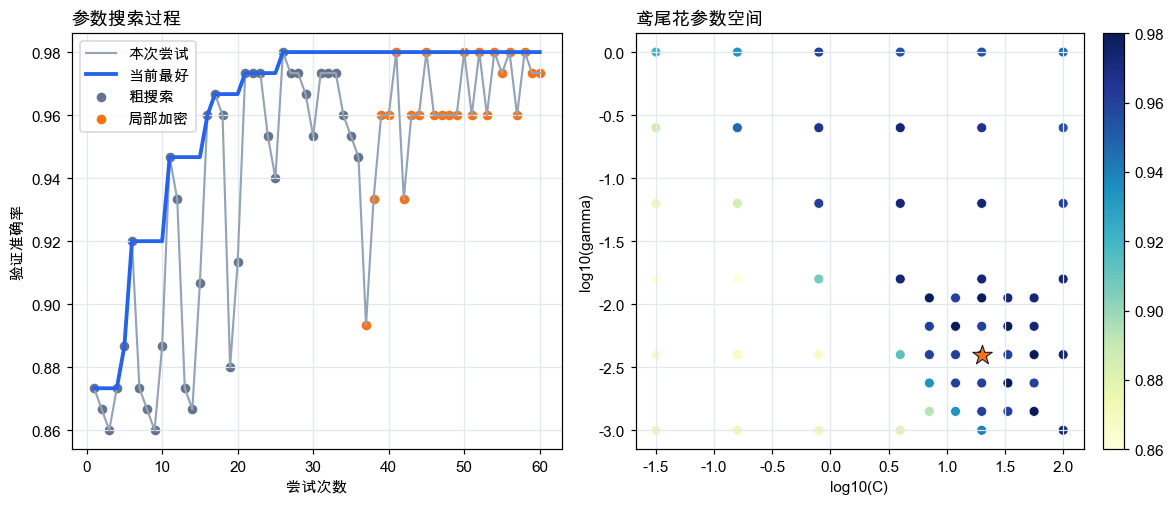

In [3]:
# 绘制超参数搜索轨迹和搜索空间中的高分区域。
fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.7))
axes[0].plot(search_df["trial"], search_df["cv_accuracy"], color="#94a3b8", linewidth=1.4, label="本次尝试")
axes[0].plot(search_df["trial"], search_df["best_accuracy"], color="#2563eb", linewidth=2.5, label="当前最好")
for phase, color in [("粗搜索", "#64748b"), ("局部加密", "#f97316")]:
    part = search_df[search_df["phase"] == phase]
    axes[0].scatter(part["trial"], part["cv_accuracy"], s=28, color=color, label=phase)
axes[0].set_title("参数搜索过程", loc="left", fontweight="bold")
axes[0].set_xlabel("尝试次数")
axes[0].set_ylabel("验证准确率")
axes[0].grid(True, color="#e2e8f0", linewidth=0.8)
axes[0].legend()

sc = axes[1].scatter(
    search_df["log10_C"],
    search_df["log10_gamma"],
    c=search_df["cv_accuracy"],
    cmap="YlGnBu",
    s=42,
    edgecolors="white",
    linewidth=0.45,
)
axes[1].scatter(best_row["log10_C"], best_row["log10_gamma"], s=180, marker="*", color="#f97316", edgecolor="#0f172a", linewidth=0.7)
axes[1].set_title("鸢尾花参数空间", loc="left", fontweight="bold")
axes[1].set_xlabel("log10(C)")
axes[1].set_ylabel("log10(gamma)")
axes[1].grid(True, color="#e2e8f0", linewidth=0.8)
fig.colorbar(sc, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()